In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import geopandas as gpd
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib
from utils.utils import state_fips
import networkx as nx


In [2]:
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
with open('network_graph.pickle', 'rb') as f:
    G1 = pickle.load(f)

In [4]:
data = []
for node, attrs in G1.nodes(data=True):
    if "county" in attrs and "state" in attrs and "population" in attrs:
        row = {
            "state": attrs["state"],
            "county": attrs["county"],
            "opinion": attrs.get("baseline_opinion"),
            "population": attrs.get("population")
        }
        data.append(row)

df = pd.DataFrame(data)

In [5]:
df.head()

,state,county,opinion,population
0,Texas,Travis County,None,1039958
1,California,Los Angeles County,None,7790871
2,California,San Francisco County,None,721592
3,Texas,Travis County,None,1039958
4,Texas,Travis County,None,1039958


# County Coverage

In [6]:
county_counts = df[['county', 'state']].value_counts().reset_index()
county_counts["name"] = county_counts["county"] + ", " + county_counts["state"]
county_counts.head()

,county,state,count,name
0,Travis County,Texas,4267,"Travis County, Texas"
1,San Francisco County,California,2051,"San Francisco County, California"
2,Los Angeles County,California,2028,"Los Angeles County, California"
3,Dallas County,Texas,1678,"Dallas County, Texas"
4,New York County,New York,1529,"New York County, New York"


### Top counts per county

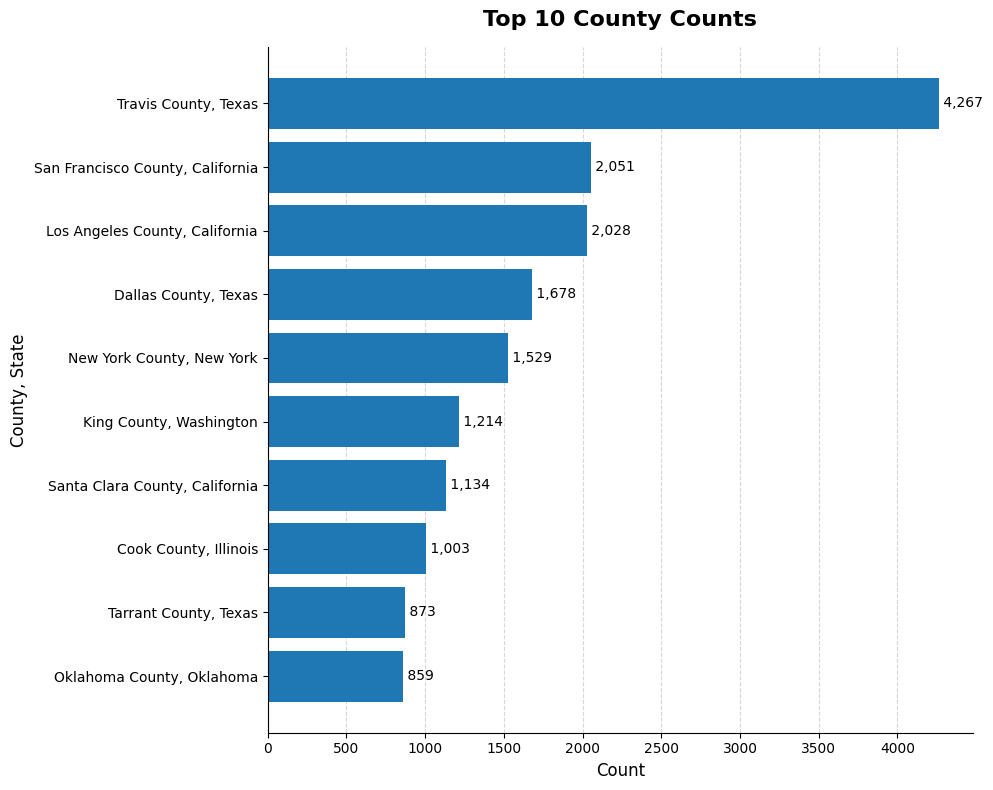

In [7]:
top_n = 10
plot_data = county_counts.head(top_n).reset_index()

plt.figure(figsize=(10, 8))

bars = plt.barh(
    plot_data['name'],
    plot_data['count']
)

# Clean style tweaks
plt.gca().invert_yaxis()
plt.xlabel('Count', fontsize=12)
plt.ylabel('County, State', fontsize=12)
plt.title(f'Top {top_n} County Counts', fontsize=16, weight='bold', pad=15)

# Remove top/right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add light gridlines for readability
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# Add value labels at end of bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' {int(width):,}',  # formatted with commas
        va='center',
        fontsize=10
    )

# Improve layout spacing
plt.tight_layout()

plt.show()

### Count per 100k residents of county

In [8]:
df_agg = df.groupby(["county", "state"], as_index=False).agg({
    "population": "first",
})

In [10]:
county_counts_with_population = county_counts.merge(df_agg, on=["county", "state"], how="left")
county_counts_with_population['count_per_100k'] = (county_counts_with_population['count'] / county_counts_with_population['population']) * 100000
county_counts_with_population = county_counts_with_population.sort_values(by=["count_per_100k"])

In [11]:
county_counts_with_population.head(5)

,county,state,count,name,population,count_per_100k
1109,Trumbull County,Ohio,1,"Trumbull County, Ohio",159836,0.625641
1133,Citrus County,Florida,1,"Citrus County, Florida",135186,0.739722
1125,Davidson County,North Carolina,1,"Davidson County, North Carolina",133783,0.747479
1201,Paulding County,Georgia,1,"Paulding County, Georgia",129489,0.772266
1043,Imperial County,California,1,"Imperial County, California",128204,0.780007


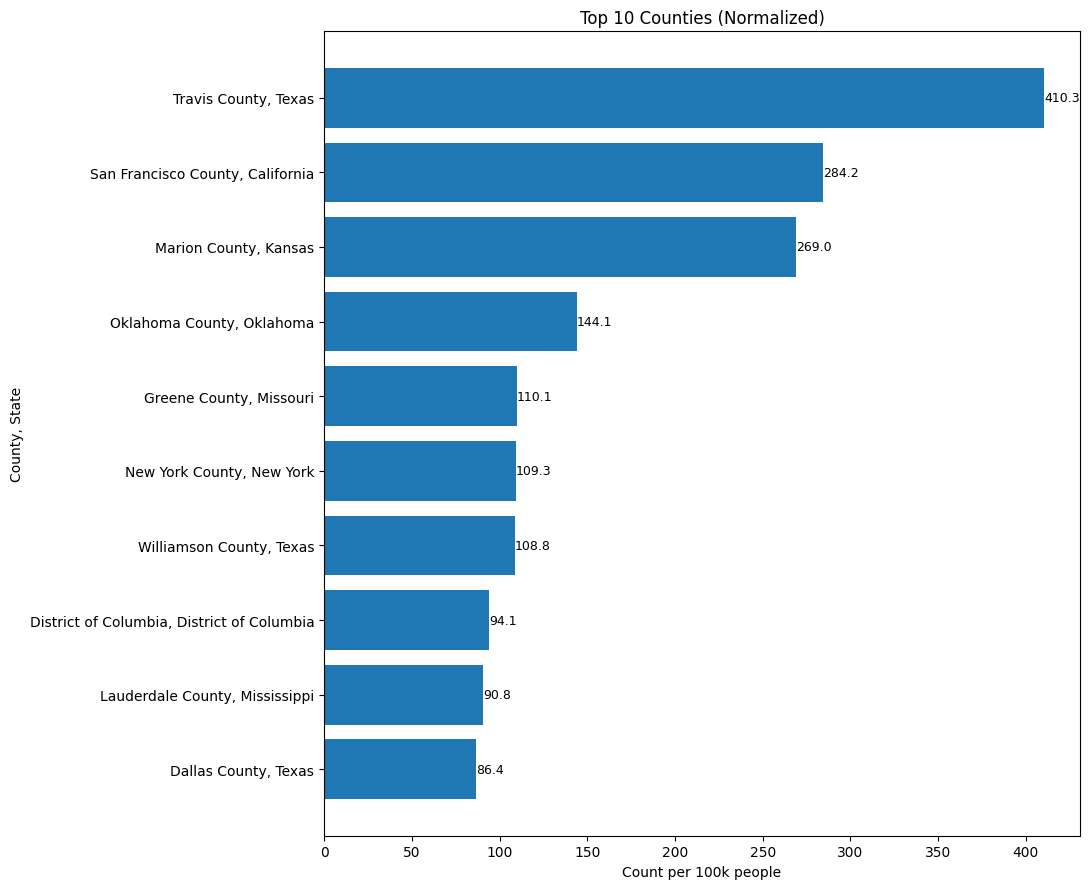

In [115]:
# plotting
plot_data_county_coverage_per_capita = county_counts_with_population.sort_values(by=["count_per_100k"], ascending=False)
plot_data_county_coverage_per_capita = plot_data_county_coverage_per_capita.head(top_n)
plt.figure(figsize=(11, 9))
bars = plt.barh(
    plot_data_county_coverage_per_capita['name'],
    plot_data_county_coverage_per_capita['count_per_100k']
)

plt.xlabel('Count per 100k people')
plt.ylabel('County, State')
plt.title(f'Top {top_n} Counties (Normalized)')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                        
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',                 
        va='center',
        ha='left',
        fontsize=9
    )
plt.tight_layout()
plt.savefig("visualizations/county_normalized_counts_top.pdf")

plt.show()

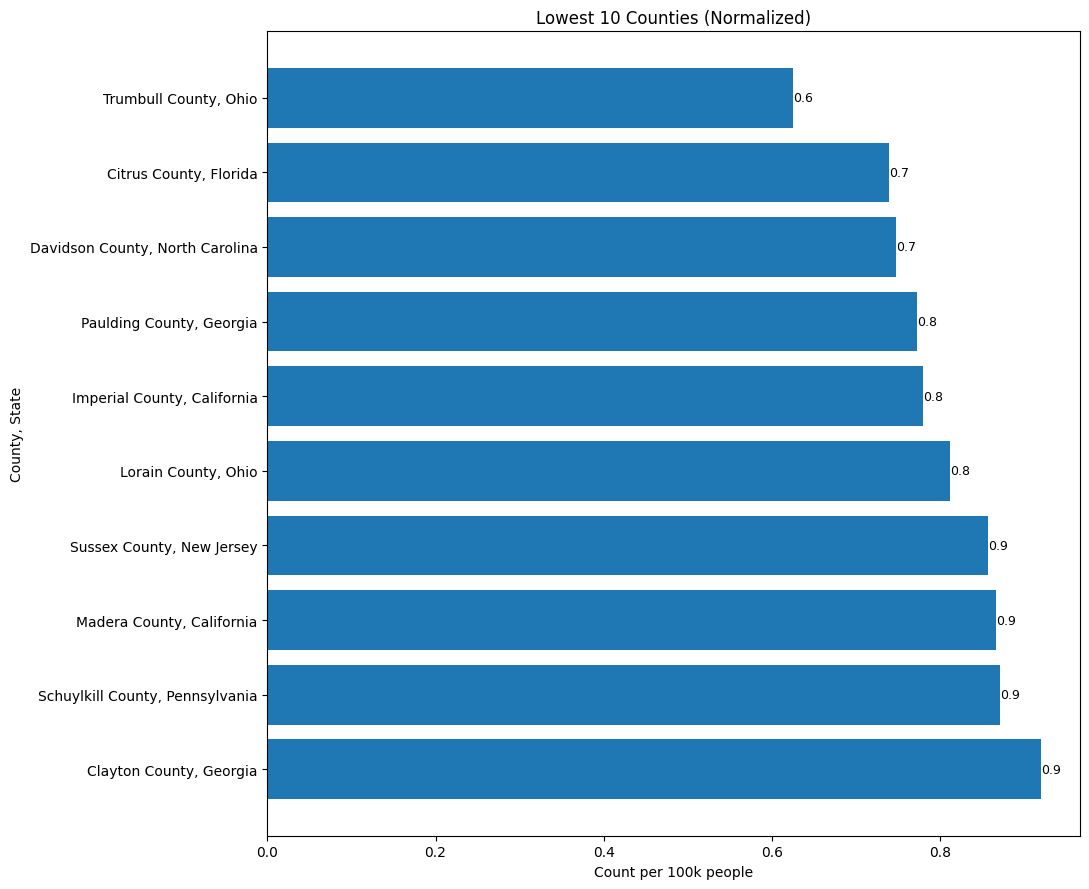

In [116]:
plot_data_county_coverage_per_capita = county_counts_with_population.sort_values(by=["count_per_100k"], ascending=True)
plot_data_county_coverage_per_capita = plot_data_county_coverage_per_capita.head(top_n)
plt.figure(figsize=(11, 9))

bars = plt.barh(
    plot_data_county_coverage_per_capita['name'],
    plot_data_county_coverage_per_capita['count_per_100k']
)

plt.xlabel('Count per 100k people')
plt.ylabel('County, State')
plt.title(f'Lowest {top_n} Counties (Normalized)')
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width,                        
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}',                 
        va='center',
        ha='left',
        fontsize=9
    )
plt.tight_layout()
plt.savefig("visualizations/county_normalized_counts_low.pdf")

plt.show()

### County coverage map

In [35]:
counties_census = gpd.read_file("tl_2024_us_county/tl_2024_us_county.shp")

In [36]:
counties_census['state'] = counties_census['STATEFP'].map(state_fips).str.upper()
counties_census['county'] = counties_census['NAME'].str.upper().str.replace(' COUNTY', '').str.strip()

mask = counties_census["state"] == "CONNECTICUT"
# applied to census counties df
counties_census.loc[mask, "county"] = (
    counties_census.loc[mask, "county"] + " PLANNING REGION"
)

In [37]:
county_counts['state'] = county_counts['state'].str.upper().str.strip()
county_counts['county'] = county_counts['county'].str.upper().str.replace(' COUNTY', '').str.strip()

mask = county_counts["state"] == "ALASKA"

county_counts.loc[mask, "county"] = (
    county_counts.loc[mask, "county"].str.replace("BOROUGH", "", regex=False).str.strip()
)

county_counts.loc[mask, "county"] = (
    county_counts.loc[mask, "county"].str.replace("CITY AND", "", regex=False).str.strip())

county_counts.loc[mask, "county"] = (
    county_counts.loc[mask, "county"].str.replace("MUNICIPALITY", "", regex=False).str.strip())

mask = county_counts["state"] == "LOUISIANA"

county_counts.loc[mask, "county"] = (
    county_counts.loc[mask, "county"].str.replace("PARISH", "", regex=False).str.strip())


In [46]:
county_counts_with_census_data = counties_census.merge(
    county_counts,
    on=['county', 'state'],
    how='left'
)

In [51]:
county_counts_with_census_data.loc[county_counts_with_census_data['count'] > 0, 'present'] = True
county_counts_with_census_data.loc[(county_counts_with_census_data['count'] == 0) | (county_counts_with_census_data['count'].isna()), 'present'] = False

C:\Users\Elizabeth\AppData\Local\Temp\ipykernel_28980\578805323.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


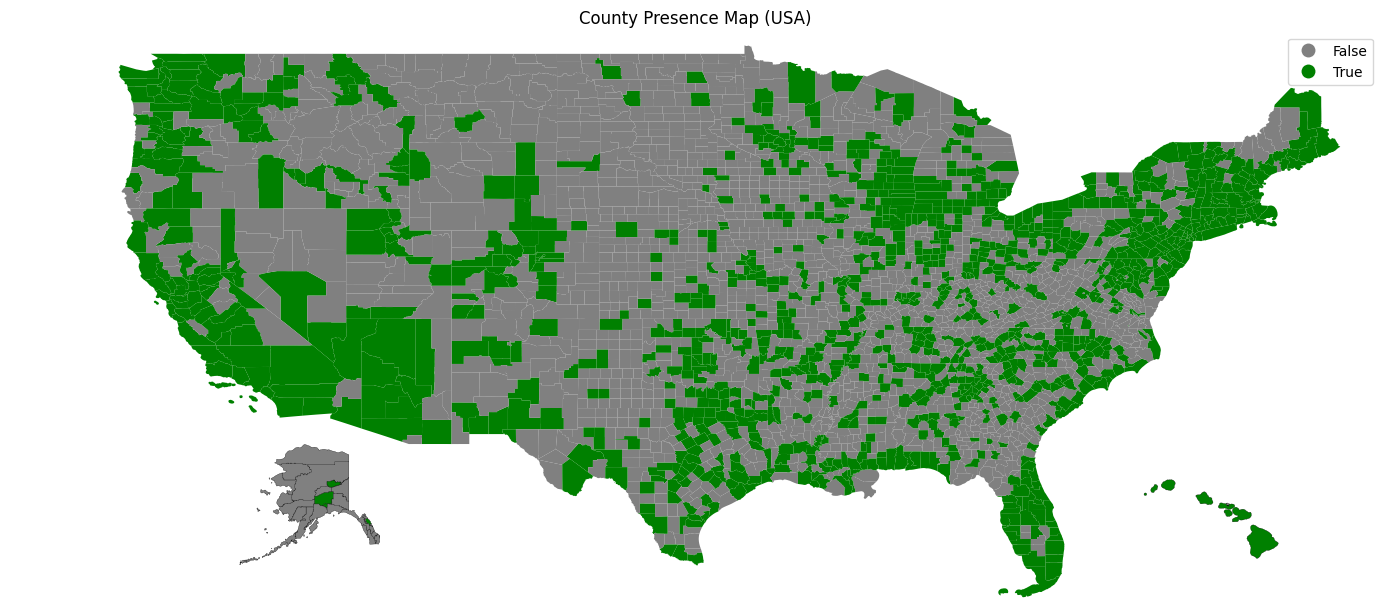

In [107]:
conus = county_counts_with_census_data[~county_counts_with_census_data['state'].isin(["ALASKA", "HAWAII"] + ["PUETRO RICO"])]
alaska = county_counts_with_census_data[county_counts_with_census_data['state'] == "ALASKA"]
hawaii = county_counts_with_census_data[county_counts_with_census_data['state'] == "HAWAII"]

# --- create figure ---
fig = plt.figure(figsize=(14, 9))
ax_main = fig.add_subplot(111)

cmap = ListedColormap(['gray', 'green'])
data = [[True, False], [False, True]]

# --- main map (CONUS) ---
conus.plot(
    column='present',
    ax=ax_main,
    cmap=cmap,
    legend=True,
    missing_kwds={"color": "lightgrey"}
)
ax_main.set_xlim(-130, -65) 
ax_main.set_ylim(24, 50)
ax_main.set_title("County Presence Map (USA)")
ax_main.axis('off')

ax_alaska = inset_axes(ax_main, width="25%", height="25%", loc='lower left', borderpad=2)

alaska.plot(
    column='present',
    ax=ax_alaska,
    cmap=cmap,
    legend=False,
    edgecolor='black',
    linewidth=0.2,
    missing_kwds={"color": "lightgrey"}
)
ax_alaska.set_xlim(-250, -130) 
ax_alaska.set_ylim(50, 72)

# ax_alaska.set_title("Alaska", fontsize=8)
ax_alaska.axis('off')

# --- Hawaii inset ---
ax_hawaii = inset_axes(ax_main, width="20%", height="20%", loc='lower right', borderpad=2)

hawaii.plot(
    column='present',
    ax=ax_hawaii,
    cmap=cmap,
    legend=False,
    edgecolor='black',
    linewidth=0.2,
    missing_kwds={"color": "lightgrey"}
)

ax_hawaii.set_xlim(-161, -154)
ax_hawaii.set_ylim(18, 23)
ax_hawaii.set_aspect('equal')
# ax_hawaii.set_title("Hawaii", fontsize=8)
ax_hawaii.axis('off')

plt.tight_layout()
plt.savefig("visualizations/county_presence_map.pdf")
plt.show()

# State Coverage

### State coverage bar plot

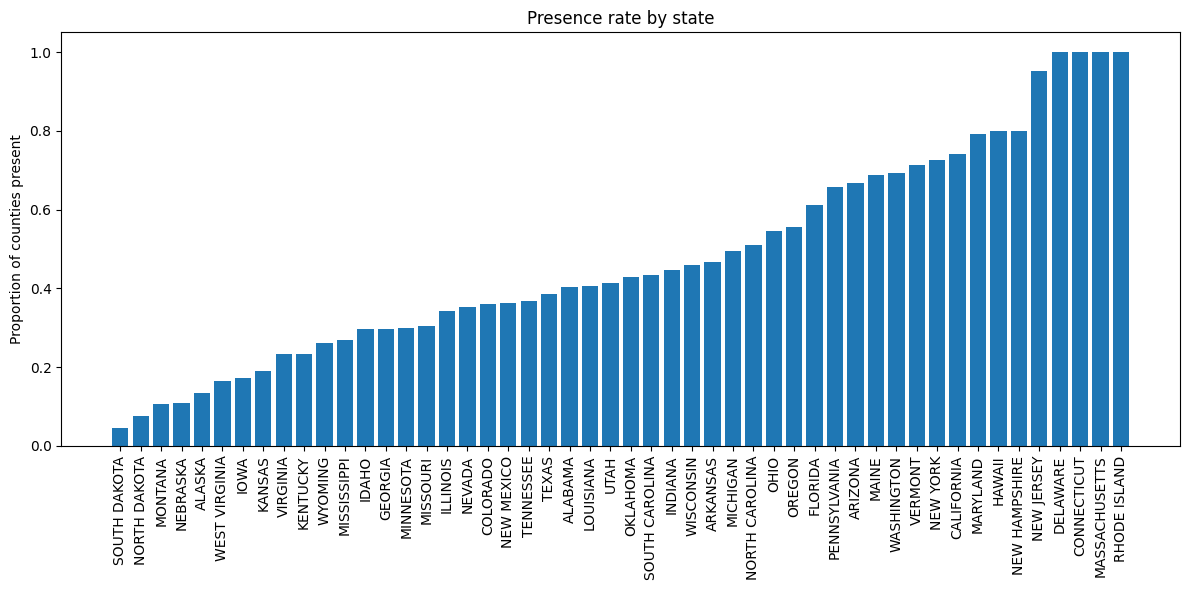

In [109]:
state_presence_summary = county_counts_with_census_data.groupby('state')['present_int'].mean().sort_values()

plt.figure(figsize=(12,6))
plt.bar(state_presence_summary.index, state_presence_summary.values)
plt.xticks(rotation=90)
plt.ylabel("Proportion of counties present")
plt.title("Presence rate by state")
plt.tight_layout()
plt.savefig("visualizations/state_presence_bar_chart.pdf")
plt.show()

### State coverage map

In [ ]:
state_gdf = county_counts_with_census_data.dissolve(
    by='state',
    aggfunc={'present_int': 'mean'}
).reset_index()

C:\Users\Elizabeth\AppData\Local\Temp\ipykernel_28980\1902483640.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


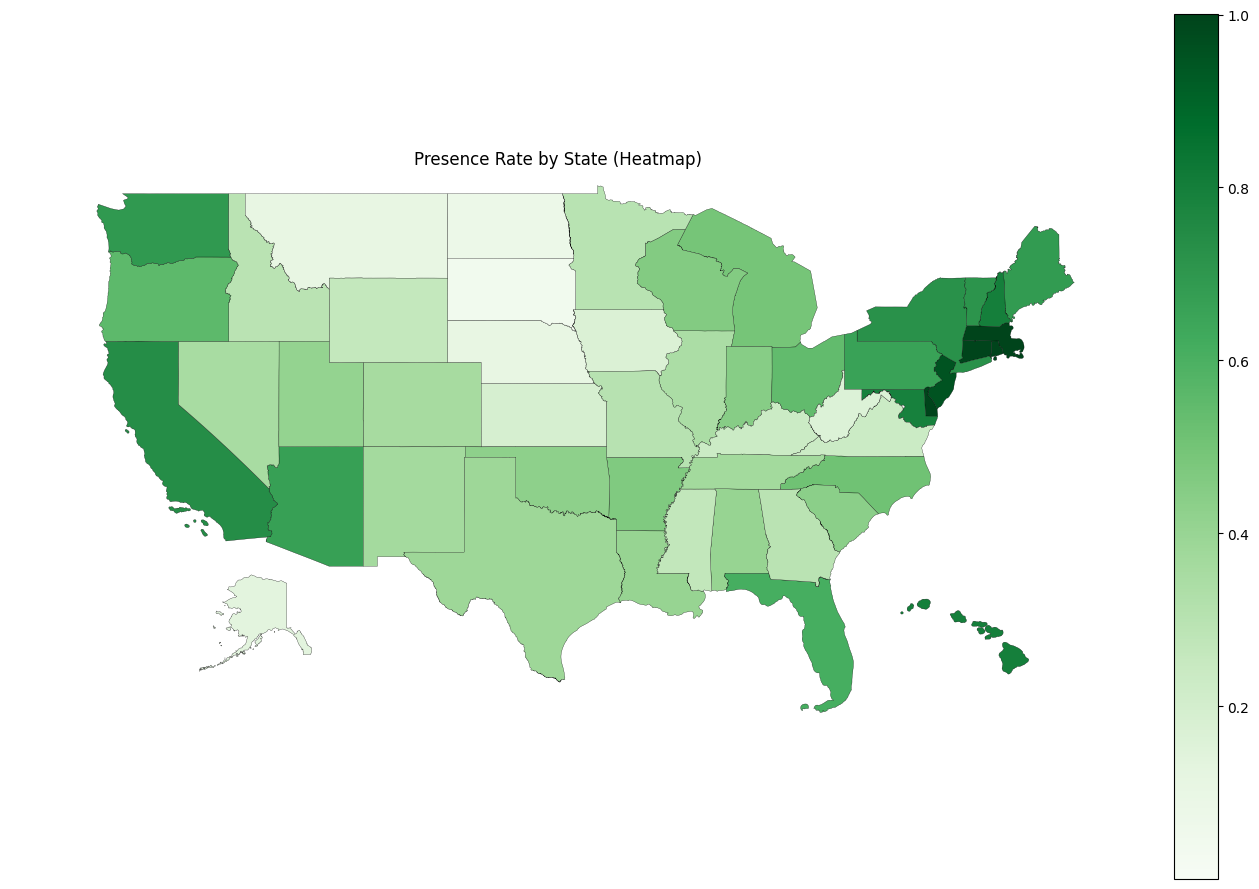

In [108]:

cmap = plt.cm.Greens.copy()
cmap.set_under("lightgray")


conus = state_gdf[~state_gdf['state'].isin(["ALASKA", "HAWAII"] + ["PUErTO RICO"])]
alaska = state_gdf[state_gdf['state'] == "ALASKA"]
hawaii = state_gdf[state_gdf['state'] == "HAWAII"]

# --- create figure ---
fig = plt.figure(figsize=(14, 9))
ax_main = fig.add_subplot(111)

data = [[True, False], [False, True]]

# --- main map (CONUS) ---
conus.plot(
    column='present_int',
    ax=ax_main,
    cmap=cmap,
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    vmin=0.0001,  # anything below this (i.e., 0) becomes gray
    vmax=1,
    missing_kwds={"color": "lightgrey"}
)
ax_main.set_xlim(-130, -65) 
ax_main.set_ylim(24, 50)
ax_main.set_title("Presence Rate by State (Heatmap)")
ax_main.axis('off')

# # --- Alaska inset ---
ax_alaska = inset_axes(ax_main, width="25%", height="25%", loc='lower left', borderpad=2)
alaska.plot(
    column='present_int',
    ax=ax_alaska,
    cmap=cmap,
    legend=False,
    edgecolor='black',
    linewidth=0.2,
    vmin=0.0001,  # anything below this (i.e., 0) becomes gray
    vmax=1,
    missing_kwds={"color": "lightgrey"}
)
ax_alaska.set_xlim(-250, -130) 
ax_alaska.set_ylim(50, 72)


# ax_alaska.set_title("Alaska", fontsize=8)
ax_alaska.axis('off')

# --- Hawaii inset ---
ax_hawaii = inset_axes(ax_main, width="20%", height="20%", loc='lower right', borderpad=2)

hawaii.plot(
    column='present_int',
    ax=ax_hawaii,
    cmap=cmap,
    legend=False,
    edgecolor='black',
    linewidth=0.2,
    vmin=0.0001,  # anything below this (i.e., 0) becomes gray
    vmax=1,
    missing_kwds={"color": "lightgrey"}
)

ax_hawaii.set_xlim(-161, -154)
ax_hawaii.set_ylim(18, 23)
ax_hawaii.set_aspect('equal')
# ax_hawaii.set_title("Hawaii", fontsize=8)
ax_hawaii.axis('off')

plt.tight_layout()
plt.savefig("visualizations/state_presence_map.pdf")
plt.show()

# Rhode Island analysis

In [103]:
state_to_analyze = "New York"

In [104]:
gowalla_state = G1.subgraph([n for n, attr in G1.nodes(data=True) if attr.get('state') == state_to_analyze])


C:\Users\Elizabeth\AppData\Local\Temp\ipykernel_28980\1207040788.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


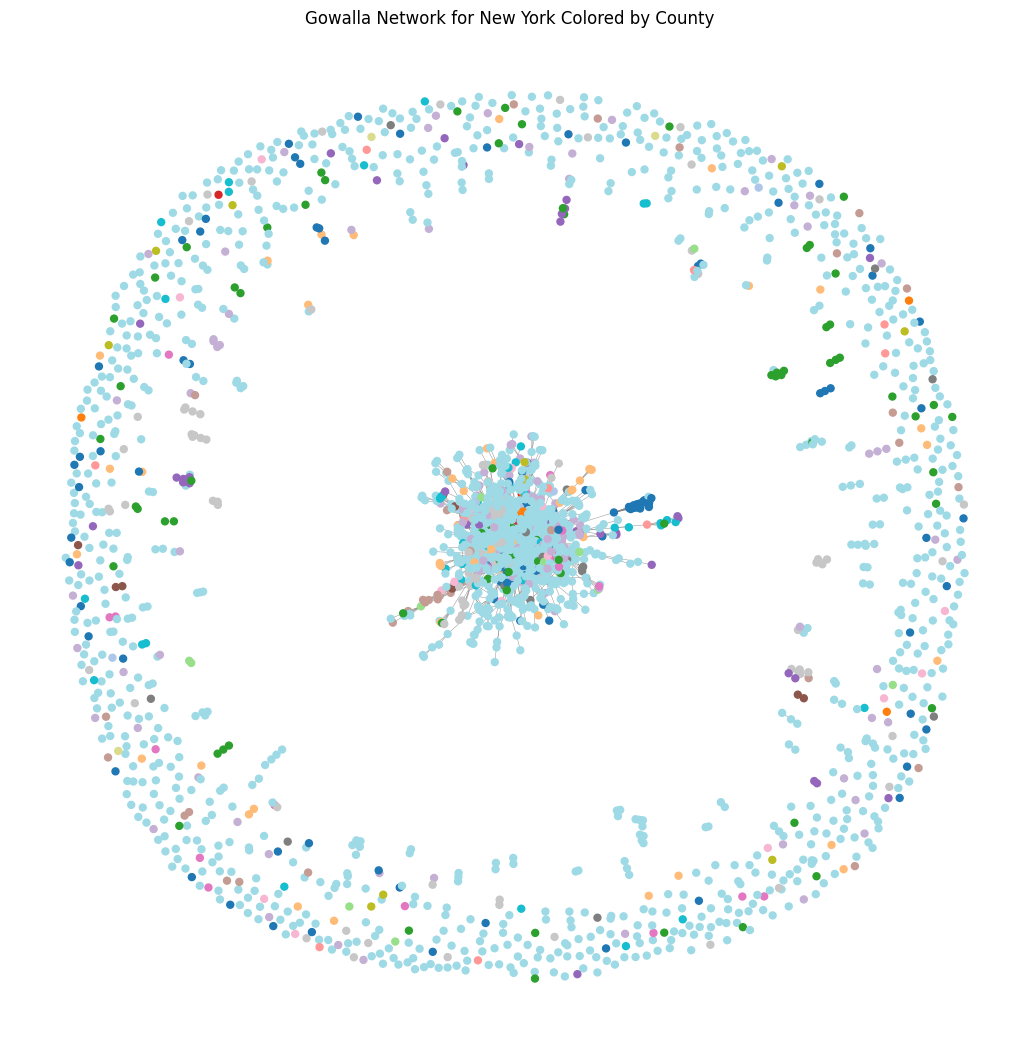

In [117]:

counties = nx.get_node_attributes(gowalla_state, "county")

# Assign a unique color to each county
unique_counties = list(set(counties.values()))
color_map = {county: i for i, county in enumerate(unique_counties)}

node_colors = [color_map[counties.get(node)] for node in gowalla_state.nodes()]

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(gowalla_state, seed=42)

nx.draw(
    gowalla_state,
    pos,
    node_size=25,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    edge_color='gray',
    width=0.3,
    with_labels=False
)

plt.title(f"Gowalla Network for {state_to_analyze} Colored by County")
plt.tight_layout()
plt.savefig("visualizations/network_graph_state")
plt.axis('off')
plt.show()